In [35]:
import pickle
import os
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import butter, filtfilt
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.inspection import permutation_importance
from torch.utils.data import DataLoader, TensorDataset
import torch.nn.functional as F

In [ ]:
DATA_DIR = r"/kaggle/input/datasets/manh123df/deap-dataset/deap-dataset/data_preprocessed_python"
SAVE_DIR = r"deap-dataset\model_ready_data"
os.makedirs(SAVE_DIR, exist_ok=True)

# Signal Processing
FS = 128
LOWCUT = 4.0
HIGHCUT = 45.0
BASELINE_SEC = 3
WINDOW_SEC = 60

BASELINE_SAMPLES = BASELINE_SEC * FS
TASK_SAMPLES = WINDOW_SEC * FS

In [2]:
def apply_bandpass_filter(data, lowcut, highcut, fs, order=4):
    nyq = 0.5 * fs
    b, a = butter(order, [lowcut / nyq, highcut / nyq], btype='band')
    return filtfilt(b, a, data, axis=-1)

def subtract_baseline(eeg_data, baseline_samples):
    baseline = eeg_data[:, :, :, :baseline_samples]
    task = eeg_data[:, :, :, baseline_samples:]
    baseline_mean = np.mean(baseline, axis=-1, keepdims=True)
    return task - baseline_mean

def subject_wise_z_score(task_data):
    print("Applying Subject-Wise & Channel-Wise Z-Score Normalization...")
    normalized_data = np.zeros_like(task_data)

    for subj_idx in range(task_data.shape[0]):
        for chan_idx in range(task_data.shape[2]):
            channel_data = task_data[subj_idx, :, chan_idx, :]
            mu = np.mean(channel_data)
            sigma = np.std(channel_data)
            normalized_data[subj_idx, :, chan_idx, :] = (channel_data - mu) / (sigma + 1e-8)

    return normalized_data

In [3]:
all_eeg = []
all_labels = []
valid_subjects = [i for i in range(1, 33) if i != 4] # Drop subject 4

for i in valid_subjects:
    file_path = os.path.join(DATA_DIR, f's{i:02d}.dat')
    with open(file_path, 'rb') as f:
        raw_data = pickle.load(f, encoding='latin1')

    all_eeg.append(raw_data['data'][:, :32, :])
    valence_scores = raw_data['labels'][:, 0]
    all_labels.append((valence_scores > 5).astype(np.float32))

X_raw = np.array(all_eeg, dtype='float32')
y_bin = np.array(all_labels, dtype='float32')

print(f"Raw Matrix Shape: {X_raw.shape}")

X_filtered = apply_bandpass_filter(X_raw, LOWCUT, HIGHCUT, FS)
X_task = subtract_baseline(X_filtered, BASELINE_SAMPLES)
X_subj= subject_wise_z_score(X_task)

print(f"\nShape: {X_subj.shape}")

Raw Matrix Shape: (31, 40, 32, 8064)
Applying Subject-Wise & Channel-Wise Z-Score Normalization...

Shape: (31, 40, 32, 7680)


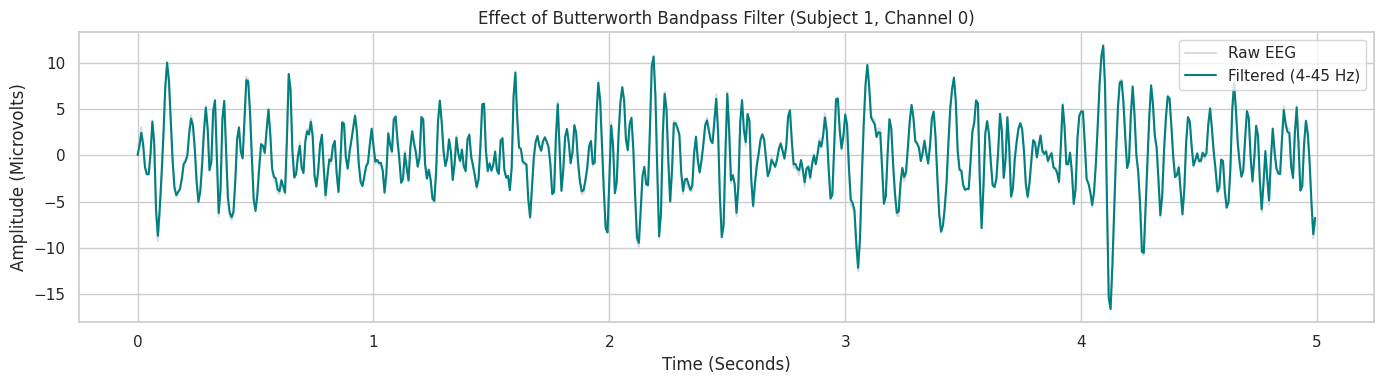

In [4]:
#filter effect viz
sns.set_theme(style="whitegrid")
time_axis = np.arange(FS * 5) / FS
plt.figure(figsize=(14, 4))
plt.plot(time_axis, X_raw[0, 0, 0, :FS*5], label="Raw EEG", color='lightgray', alpha=0.8)
plt.plot(time_axis, X_filtered[0, 0, 0, :FS*5], label="Filtered (4-45 Hz)", color='teal', linewidth=1.5)
plt.title(f"Effect of Butterworth Bandpass Filter (Subject {valid_subjects[0]}, Channel 0)", fontsize=12)
plt.xlabel("Time (Seconds)")
plt.ylabel("Amplitude (Microvolts)")
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()


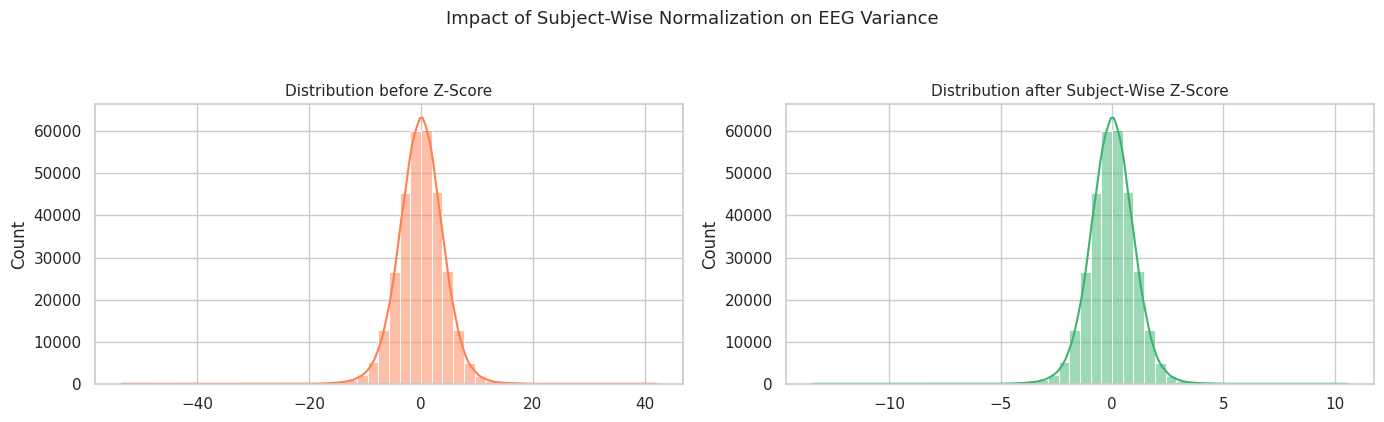

In [5]:
# Z-Score Impact Viz
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
raw_dist = X_task[0, :, 0, :].flatten()
norm_dist = X_subj[0, :, 0, :].flatten()
sns.histplot(raw_dist, bins=50, ax=axes[0], color='coral', kde=True)
axes[0].set_title("Distribution before Z-Score", fontsize=11)
sns.histplot(norm_dist, bins=50, ax=axes[1], color='mediumseagreen', kde=True)
axes[1].set_title("Distribution after Subject-Wise Z-Score", fontsize=11)
plt.suptitle("Impact of Subject-Wise Normalization on EEG Variance", fontsize=13, y=1.05)
plt.tight_layout()
plt.show()

/tmp/ipykernel_57/1350667453.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['Low Valence (<=5)', 'High Valence (>5)'], y=class_counts, palette=['crimson', 'steelblue'])


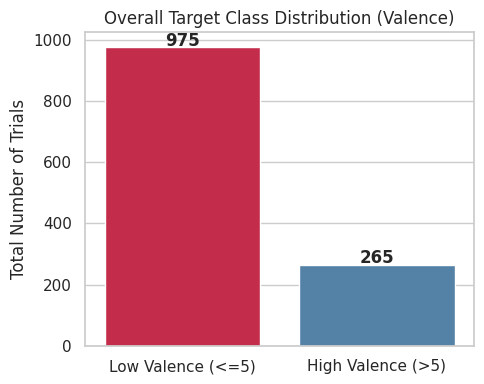

In [130]:
#Class Balance
plt.figure(figsize=(5, 4))
class_counts = [np.sum(y_bin == 0), np.sum(y_bin == 1)]
sns.barplot(x=['Low Valence (<=5)', 'High Valence (>5)'], y=class_counts, palette=['crimson', 'steelblue'])
plt.title("Overall Target Class Distribution (Valence)", fontsize=12)
plt.ylabel("Total Number of Trials")
for i, count in enumerate(class_counts):
    plt.text(i, count + 5, str(int(count)), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

In [7]:
X_flat = X_subj.reshape(-1, X_subj.shape[2], X_subj.shape[3]) # flatten the subject and trial dimensions
y_flat = y_bin.reshape(-1) # reshaping from (31, 40, 32, 7680) to (1240, 32, 7680)
groups = np.repeat(np.arange(X_subj.shape[0]), X_subj.shape[1])
X_tensor = torch.tensor(X_flat, dtype=torch.float32)
y_tensor = torch.tensor(y_flat, dtype=torch.float32)
groups_tensor = torch.tensor(groups, dtype=torch.long)
torch.save(X_tensor, os.path.join(SAVE_DIR, 'X_cleaned_deap.pt'))
torch.save(y_tensor, os.path.join(SAVE_DIR, 'y_valence_bin.pt'))
torch.save(groups_tensor, os.path.join(SAVE_DIR, 'groups_loso.pt'))

print(f"\nSaved to: {SAVE_DIR}")
print(f"X_tensor: {X_tensor.shape}")
print(f"y_tensor: {y_tensor.shape}")
print(f"groups: {groups_tensor.shape}")


Saved to: deap-dataset\model_ready_data
X_tensor: torch.Size([1240, 32, 7680])
y_tensor: torch.Size([1240])
groups: torch.Size([1240])


In [8]:
import random
from torch.utils.data import TensorDataset, DataLoader

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Downsample to make training faster

def downsample_mean(x, factor=32):
    n, c, t = x.shape
    t_trim = t - (t % factor)
    x = x[:, :, :t_trim]
    x = x.reshape(n, c, t_trim // factor, factor).mean(-1)
    return x

X_ds = downsample_mean(X_tensor, factor=32)
print("Downsampled shape:", X_ds.shape)

# Subject-wise split
subjects = torch.unique(groups_tensor).numpy()
rng = np.random.default_rng(SEED)
num_test = max(1, int(0.2 * len(subjects)))
test_subjects = rng.choice(subjects, size=num_test, replace=False)

test_mask = torch.isin(groups_tensor, torch.tensor(test_subjects))
train_mask = ~test_mask

X_train = X_ds[train_mask]
y_train = y_tensor[train_mask]
X_test = X_ds[test_mask]
y_test = y_tensor[test_mask]

train_ds = TensorDataset(X_train, y_train)
test_ds = TensorDataset(X_test, y_test)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=64, shuffle=False)

print("Train size:", len(train_ds), "Test size:", len(test_ds))

# Metrics helpers

def accuracy_from_logits(logits, y_true):
    probs = torch.sigmoid(logits).squeeze()
    preds = (probs >= 0.5).float()
    return (preds == y_true).float().mean().item()

@torch.no_grad()
def evaluate_model(model, loader):
    model.eval()
    accs = []
    for xb, yb in loader:
        logits = model(xb)
        accs.append(accuracy_from_logits(logits, yb))
    return float(np.mean(accs))

@torch.no_grad()
def batch_accuracy(model, x, y):
    logits = model(x)
    probs = torch.sigmoid(logits).squeeze()
    preds = (probs >= 0.5).float()
    return (preds == y).float().mean().item()

# MNE montage for channel layout
try:
    import mne
except ImportError as e:
    raise ImportError("Please install MNE: pip install mne") from e

ch_names = [
    "Fp1","AF3","F3","F7","FC5","FC1","C3","T7",
    "CP5","CP1","P3","P7","PO3","O1","Oz","Pz",
    "Fp2","AF4","Fz","F4","F8","FC6","FC2","Cz",
    "C4","T8","CP6","CP2","P4","P8","PO4","O2"
]
info = mne.create_info(ch_names=ch_names, sfreq=FS, ch_types="eeg")
montage = mne.channels.make_standard_montage("standard_1020")
info.set_montage(montage)

def plot_topomap(values, title):
    fig, ax = plt.subplots(figsize=(4, 3))
    mne.viz.plot_topomap(values, info, axes=ax, show=False)
    ax.set_title(title)
    plt.show()

Downsampled shape: torch.Size([1240, 32, 240])
Train size: 1000 Test size: 240


implementing the first 2 models modelsssssssssssssssssssss 





karim wael 

In [9]:
# Build a simple adjacency matrix from electrode distances
pos = np.array([info['chs'][i]['loc'][:3] for i in range(len(ch_names))])

# Pairwise distances
D = np.linalg.norm(pos[:, None, :] - pos[None, :, :], axis=-1)

# Connect each node to its k nearest neighbors
k = 4
adj = np.zeros((len(ch_names), len(ch_names)), dtype=np.float32)
for i in range(len(ch_names)):
    nn_idx = np.argsort(D[i])[1:k+1]
    adj[i, nn_idx] = 1.0
    adj[nn_idx, i] = 1.0

# Add self-connections
np.fill_diagonal(adj, 1.0)
adj_tensor = torch.tensor(adj, dtype=torch.float32)


In [11]:
import torch.nn as nn

architecture of the 3 models

In [12]:
class BrainCompetition(nn.Module):
    def __init__(self, bands=5, hidden=32):
        super().__init__()
        self.band_att = nn.Linear(bands, bands)
        self.channel_fc = nn.Linear(bands, hidden)
        self.comp = nn.Linear(hidden, 1)
        self.out = nn.Linear(hidden, 1)

    def forward(self, x, return_attention=False):
        # x: (batch, channels, bands)
        att_logits = self.band_att(x)
        att = torch.softmax(att_logits, dim=-1)
        x_weighted = att * x

        h = torch.relu(self.channel_fc(x_weighted))
        comp_logits = self.comp(h).squeeze(-1)
        comp = torch.softmax(comp_logits, dim=-1)
        pooled = (comp.unsqueeze(-1) * h).sum(dim=1)
        out = self.out(pooled)

        if return_attention:
            return out, att, comp
        return out

In [18]:
adj_tensor = adj_tensor

def train_model_weighted(model, train_loader, test_loader, epochs=10, lr=1e-3):
    model = model

    pos = (y_train == 1).sum().item()
    neg = (y_train == 0).sum().item()
    pos_weight = torch.tensor([neg / max(pos, 1)], dtype=torch.float32)

    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    for epoch in range(1, epochs + 1):
        model.train()

        for xb, yb in train_loader:
            xb = xb
            yb = yb

            optimizer.zero_grad()
            logits = model(xb).squeeze()
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

        acc = evaluate_model(model, test_loader)
        print(f"Epoch {epoch} | Test Acc: {acc:.4f}")

    return model


def evaluate_model(model, loader):
    model.eval()
    all_acc = []

    with torch.no_grad():
        for xb, yb in loader:
            xb = xb
            yb = yb

            logits = model(xb)
            acc = accuracy_from_logits(logits, yb)
            all_acc.append(acc)

    return np.mean(all_acc)


def batch_accuracy(model, xb, yb):
    model.eval()

    with torch.no_grad():
        xb = xb
        yb = yb
        logits = model(xb)
        acc = accuracy_from_logits(logits, yb)

    return acc

third model brain competition

In [27]:
# processing for the third model 



from scipy.signal import welch

# Brain rhythm bandpower features for the brain-inspired model
band_ranges = [(1, 4), (4, 8), (8, 13), (13, 30), (30, 45)]

def compute_bandpower(x, fs, bands):
    n, c, t = x.shape
    feats = np.zeros((n, c, len(bands)), dtype=np.float32)
    for i in range(n):
        for ch in range(c):
            f, psd = welch(x[i, ch], fs=fs, nperseg=256)
            for b, (low, high) in enumerate(bands):
                idx = (f >= low) & (f <= high)
                feats[i, ch, b] = psd[idx].mean()
        if (i + 1) % 100 == 0:
            print("Processed", i + 1, "samples")
    return feats

if "X_band_tensor" not in globals():
    X_band = compute_bandpower(X_tensor.numpy(), FS, band_ranges)
    X_band_tensor = torch.tensor(X_band, dtype=torch.float32)

X_band_train = X_band_tensor[train_mask]
X_band_test = X_band_tensor[test_mask]
train_loader_band = DataLoader(TensorDataset(X_band_train, y_train), batch_size=32, shuffle=True)
test_loader_band = DataLoader(TensorDataset(X_band_test, y_test), batch_size=64, shuffle=False)

print("Bandpower shape:", X_band_tensor.shape)

Processed 100 samples
Processed 200 samples
Processed 300 samples
Processed 400 samples
Processed 500 samples
Processed 600 samples
Processed 700 samples
Processed 800 samples
Processed 900 samples
Processed 1000 samples
Processed 1100 samples
Processed 1200 samples
Bandpower shape: torch.Size([1240, 32, 5])


In [32]:
print("Training BrainCompetition...")

brain = BrainCompetition(
    bands=5,
    hidden=32
)

brain = train_model_weighted(
    brain,
    train_loader_band,
    test_loader_band,
    epochs=15,
    lr=1e-3
)

brain_acc = evaluate_model(brain, test_loader_band)
print("BrainCompetition Test Accuracy:", brain_acc)

Training BrainCompetition...
Epoch 1 | Test Acc: 0.2826
Epoch 2 | Test Acc: 0.2826
Epoch 3 | Test Acc: 0.2826
Epoch 4 | Test Acc: 0.2826
Epoch 5 | Test Acc: 0.2826
Epoch 6 | Test Acc: 0.2826
Epoch 7 | Test Acc: 0.2826
Epoch 8 | Test Acc: 0.2826
Epoch 9 | Test Acc: 0.2826
Epoch 10 | Test Acc: 0.2826
Epoch 11 | Test Acc: 0.2826
Epoch 12 | Test Acc: 0.2826
Epoch 13 | Test Acc: 0.5247
Epoch 14 | Test Acc: 0.7174
Epoch 15 | Test Acc: 0.7174
BrainCompetition Test Accuracy: 0.7174479216337204


In [ ]:
adj_tensor = adj_tensor

def train_model_weighted(model, train_loader, test_loader, epochs=10, lr=1e-3):
    model = model

    pos = (y_train == 1).sum().item()
    neg = (y_train == 0).sum().item()
    pos_weight = torch.tensor([neg / max(pos, 1)], dtype=torch.float32)

    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    for epoch in range(1, epochs + 1):
        model.train()

        for xb, yb in train_loader:
            xb = xb
            yb = yb

            optimizer.zero_grad()
            logits = model(xb).squeeze()
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

        acc = evaluate_model(model, test_loader)
        print(f"Epoch {epoch} | Test Acc: {acc:.4f}")

    return model


def evaluate_model(model, loader):
    model.eval()
    all_acc = []

    with torch.no_grad():
        for xb, yb in loader:
            xb = xb
            yb = yb

            logits = model(xb)
            acc = accuracy_from_logits(logits, yb)
            all_acc.append(acc)

    return np.mean(all_acc)


def batch_accuracy(model, xb, yb):
    model.eval()

    with torch.no_grad():
        xb = xb
        yb = yb
        logits = model(xb)
        acc = accuracy_from_logits(logits, yb)

    return acc

BrainCompetition
Accuracy: 0.7208333333333333
              precision    recall  f1-score   support

         0.0       0.72      1.00      0.84       173
         1.0       0.00      0.00      0.00        67

    accuracy                           0.72       240
   macro avg       0.36      0.50      0.42       240
weighted avg       0.52      0.72      0.60       240



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


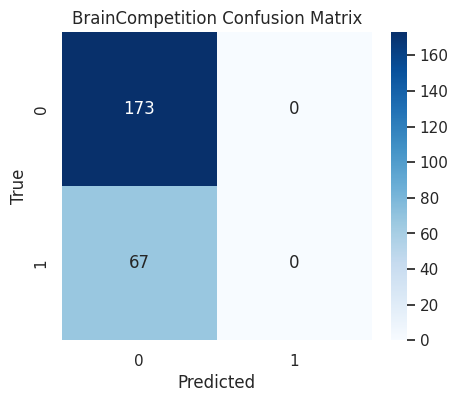

In [66]:
brain_acc = evaluate_and_visualize(
    brain,
    test_loader_band,
    "BrainCompetition"
)

4 xai interpretable techniques 

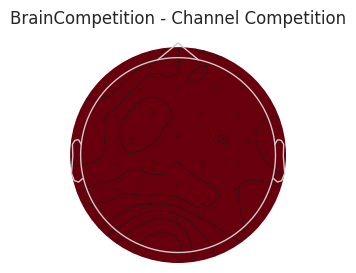

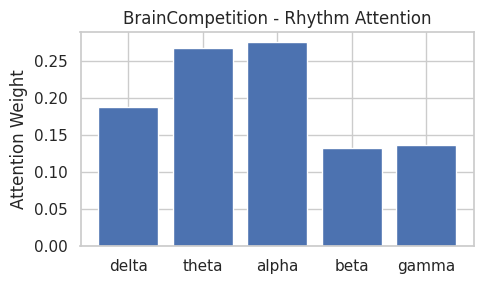

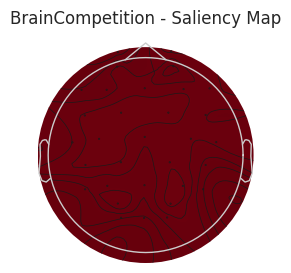

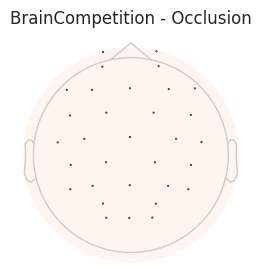

In [33]:
X_band_explain = X_band_test[:128]
y_explain = y_test[:128]

brain.eval()

# 1) Channel Competition
with torch.no_grad():
    logits, att, comp = brain(X_band_explain, return_attention=True)

    channel_importance = comp.mean(0).detach().numpy()
    plot_topomap(channel_importance, "BrainCompetition - Channel Competition")

# 2) Rhythm / Band Attention
with torch.no_grad():
    band_importance = att.mean(dim=(0, 1)).detach().numpy()

plt.figure(figsize=(5, 3))
plt.bar(["delta", "theta", "alpha", "beta", "gamma"], band_importance)
plt.title("BrainCompetition - Rhythm Attention")
plt.ylabel("Attention Weight")
plt.tight_layout()
plt.show()

# 3) Saliency
X_grad = X_band_explain.clone().detach().requires_grad_(True)

logits = brain(X_grad)
loss = nn.BCEWithLogitsLoss()(logits.squeeze(), y_explain)
loss.backward()

saliency = X_grad.grad.abs().mean(dim=2).mean(dim=0).detach().numpy()
plot_topomap(saliency, "BrainCompetition - Saliency Map")

# 4) Occlusion
base_acc = batch_accuracy(brain, X_band_explain, y_explain)
occlusion_scores = []

for ch in range(X_band_explain.shape[1]):
    x_masked = X_band_explain.clone()
    x_masked[:, ch, :] = 0.0

    acc = batch_accuracy(brain, x_masked, y_explain)
    occlusion_scores.append(base_acc - acc)

plot_topomap(np.array(occlusion_scores), "BrainCompetition - Occlusion")

the fourth model Model 4: AlexNet + PCA + SVM

In [53]:
# AlexNet works better with image-like input
# We convert EEG from (batch, channels, time) to (batch, 1, 224, 224)

def eeg_to_alex_input(x):
    # x shape: (batch, 32, time)
    x = x.unsqueeze(1)  # (batch, 1, 32, time)
    x = F.interpolate(x, size=(224, 224), mode="bilinear", align_corners=False)
    return x


alex_train_loader = DataLoader(
    TensorDataset(X_train, y_train),
    batch_size=8,
    shuffle=True
)

alex_test_loader = DataLoader(
    TensorDataset(X_test, y_test),
    batch_size=16,
    shuffle=False
)

Cell 3 — AlexNet feature extractor

In [54]:
class SimpleAlexNetEEG(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size=11, stride=4, padding=2),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2),

            nn.Conv2d(64, 192, kernel_size=5, padding=2),
            nn.BatchNorm2d(192),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2),

            nn.Conv2d(192, 384, kernel_size=3, padding=1),
            nn.BatchNorm2d(384),
            nn.ReLU(),

            nn.Conv2d(384, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),

            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2)
        )

        self.pool = nn.AdaptiveAvgPool2d((1, 1))

        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 1)
        )

    def forward(self, x, return_features=False):
        x = eeg_to_alex_input(x)
        feat_map = self.features(x)
        pooled = self.pool(feat_map).view(x.size(0), -1)

        out = self.classifier(pooled)

        if return_features:
            return out, pooled, feat_map

        return out

Cell 4 — Train AlexNet backbone

In [68]:
print("Training AlexNet EEG backbone...")

alex_model = SimpleAlexNetEEG()

alex_model = train_model_weighted(
    alex_model,
    alex_train_loader,
    alex_test_loader,
    epochs=15,
    lr=0.0003
)

alex_backbone_acc = evaluate_model(alex_model, alex_test_loader)
print("AlexNet backbone accuracy:", alex_backbone_acc)

Training AlexNet EEG backbone...
Epoch 1 | Test Acc: 0.6792
Epoch 2 | Test Acc: 0.6000
Epoch 3 | Test Acc: 0.2917
Epoch 4 | Test Acc: 0.3333
Epoch 5 | Test Acc: 0.2792
Epoch 6 | Test Acc: 0.7208
Epoch 7 | Test Acc: 0.4708
Epoch 8 | Test Acc: 0.6833
Epoch 9 | Test Acc: 0.5375
Epoch 10 | Test Acc: 0.7125
Epoch 11 | Test Acc: 0.2958
Epoch 12 | Test Acc: 0.7083
Epoch 13 | Test Acc: 0.5542
Epoch 14 | Test Acc: 0.7208
Epoch 15 | Test Acc: 0.4583
Epoch 16 | Test Acc: 0.2792
Epoch 17 | Test Acc: 0.5125
Epoch 18 | Test Acc: 0.3292
Epoch 19 | Test Acc: 0.2958
Epoch 20 | Test Acc: 0.5042
AlexNet backbone accuracy: 0.5041666666666667


Cell 5 — Extract AlexNet features + PCA + SVM

In [69]:
def extract_alex_features(model, loader):
    model.eval()
    all_features = []
    all_labels = []

    with torch.no_grad():
        for xb, yb in loader:
            xb = xb

            logits, features, feat_map = model(xb, return_features=True)

            all_features.append(features.numpy())
            all_labels.append(yb.numpy())

    all_features = np.vstack(all_features)
    all_labels = np.concatenate(all_labels)

    return all_features, all_labels


X_train_feat, y_train_np = extract_alex_features(alex_model, alex_train_loader)
X_test_feat, y_test_np = extract_alex_features(alex_model, alex_test_loader)

print("Alex features train:", X_train_feat.shape)
print("Alex features test:", X_test_feat.shape)

# PCA before SVM
pca = PCA(n_components=0.95, random_state=42)
X_train_pca = pca.fit_transform(X_train_feat)
X_test_pca = pca.transform(X_test_feat)

print("PCA train shape:", X_train_pca.shape)
print("Explained variance:", pca.explained_variance_ratio_.sum())

# SVM classifier
alex_svm = SVC(
    kernel="rbf",
    C=5,
    gamma="scale",
    class_weight="balanced",
    probability=True,
    random_state=42
)

alex_svm.fit(X_train_pca, y_train_np)

alex_svm_pred = alex_svm.predict(X_test_pca)
alex_svm_acc = accuracy_score(y_test_np, alex_svm_pred)

print("AlexNet + PCA + SVM Accuracy:", alex_svm_acc)
print(classification_report(y_test_np, alex_svm_pred))

Alex features train: (1000, 256)
Alex features test: (240, 256)
PCA train shape: (1000, 4)
Explained variance: 0.9821816
AlexNet + PCA + SVM Accuracy: 0.6708333333333333
              precision    recall  f1-score   support

         0.0       0.72      0.88      0.79       173
         1.0       0.30      0.13      0.19        67

    accuracy                           0.67       240
   macro avg       0.51      0.51      0.49       240
weighted avg       0.61      0.67      0.62       240



Cell 6 — Visualize AlexNet + SVM results

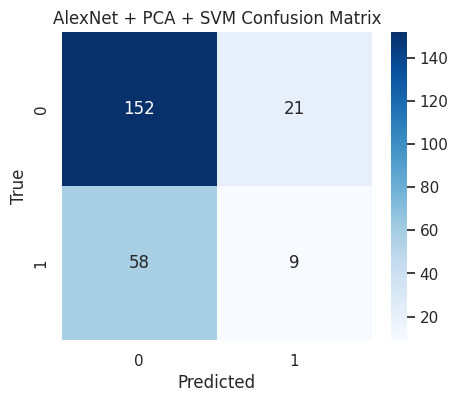

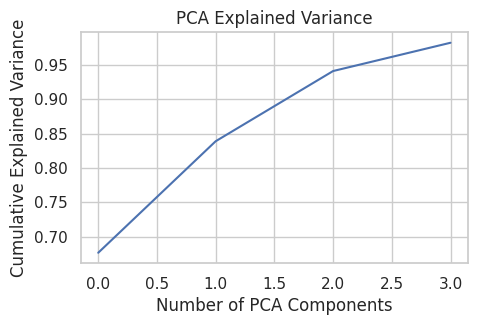

In [70]:
cm = confusion_matrix(y_test_np, alex_svm_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("AlexNet + PCA + SVM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

plt.figure(figsize=(5, 3))
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.title("PCA Explained Variance")
plt.xlabel("Number of PCA Components")
plt.ylabel("Cumulative Explained Variance")
plt.grid(True)
plt.show()

Cell 7 — 4 XAI techniques for AlexNet + PCA + SVM

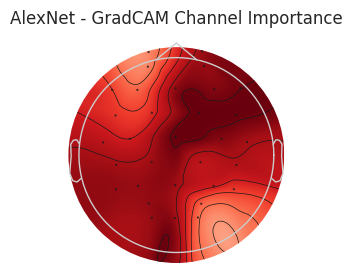

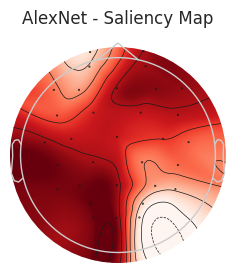

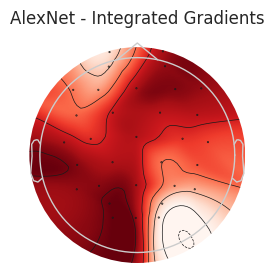

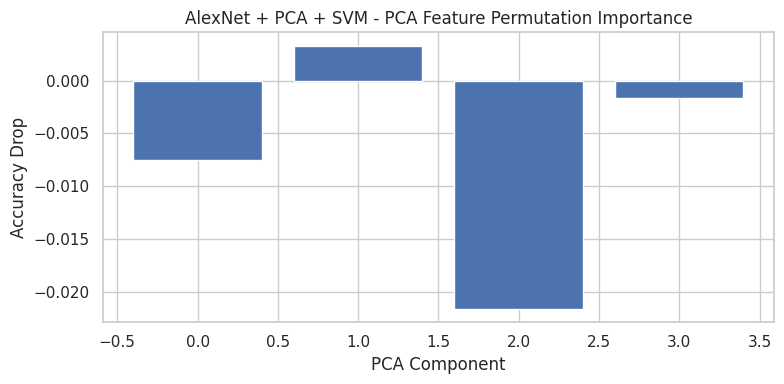

In [71]:
X_explain = X_test[:64]
y_explain = y_test[:64]

alex_model.eval()

# 1) Grad-CAM style channel importance
features_saved = None
grads_saved = None

def save_features(module, inp, out):
    global features_saved
    features_saved = out

def save_grads(module, grad_in, grad_out):
    global grads_saved
    grads_saved = grad_out[0]

last_conv = alex_model.features[-3]
hook1 = last_conv.register_forward_hook(save_features)
hook2 = last_conv.register_full_backward_hook(save_grads)

logits = alex_model(X_explain)
loss = nn.BCEWithLogitsLoss()(logits.squeeze(), y_explain)
alex_model.zero_grad()
loss.backward()

weights = grads_saved.mean(dim=(2, 3), keepdim=True)
cam = (weights * features_saved).sum(dim=1)
cam = torch.relu(cam)
cam = F.interpolate(cam.unsqueeze(1), size=(32, X_explain.shape[2]), mode="bilinear", align_corners=False)
cam_channel = cam.squeeze(1).mean(dim=(0, 2)).detach().numpy()

plot_topomap(cam_channel, "AlexNet - GradCAM Channel Importance")

hook1.remove()
hook2.remove()

# 2) Saliency Map
X_grad = X_explain.clone().detach().requires_grad_(True)

logits = alex_model(X_grad)
loss = nn.BCEWithLogitsLoss()(logits.squeeze(), y_explain)
loss.backward()

saliency = X_grad.grad.abs().mean(dim=(0, 2)).detach().numpy()
plot_topomap(saliency, "AlexNet - Saliency Map")

# 3) Integrated Gradients
steps = 20
baseline = torch.zeros_like(X_explain)
ig_total = torch.zeros_like(X_explain)

for alpha in torch.linspace(0, 1, steps):
    x_step = baseline + alpha * (X_explain - baseline)
    x_step = x_step.clone().detach().requires_grad_(True)

    logits = alex_model(x_step)
    loss = nn.BCEWithLogitsLoss()(logits.squeeze(), y_explain)

    grads = torch.autograd.grad(loss, x_step)[0]
    ig_total += grads

ig = (X_explain - baseline) * ig_total / steps
ig_importance = ig.abs().mean(dim=(0, 2)).detach().numpy()

plot_topomap(ig_importance, "AlexNet - Integrated Gradients")

# 4) SVM permutation importance on PCA features
perm = permutation_importance(
    alex_svm,
    X_test_pca,
    y_test_np,
    scoring="accuracy",
    n_repeats=5,
    random_state=42
)

plt.figure(figsize=(8, 4))
plt.bar(range(len(perm.importances_mean)), perm.importances_mean)
plt.title("AlexNet + PCA + SVM - PCA Feature Permutation Importance")
plt.xlabel("PCA Component")
plt.ylabel("Accuracy Drop")
plt.tight_layout()
plt.show()

the laaaaaast modelllllll Model 5: Transformer + Dual Temporal Attention + BiLSTM + Additive Fusion (optimized)
model architecture 

In [104]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.65, gamma=2):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, logits, targets):
        bce = F.binary_cross_entropy_with_logits(
            logits.squeeze(),
            targets,
            reduction="none"
        )

        probs = torch.sigmoid(logits.squeeze())
        pt = torch.where(targets == 1, probs, 1 - probs)

        loss = self.alpha * (1 - pt) ** self.gamma * bce
        return loss.mean()


def train_model_best(model, train_loader, test_loader, epochs=30, lr=1e-4):
    model = model

    criterion = FocalLoss(alpha=0.75, gamma=2)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="max",
        patience=3,
        factor=0.5
    )

    best_acc = 0
    best_state = None

    for epoch in range(1, epochs + 1):
        model.train()

        for xb, yb in train_loader:
            xb = xb
            yb = yb

            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()

            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

            optimizer.step()

        acc = evaluate_model(model, test_loader)
        scheduler.step(acc)

        if acc > best_acc:
            best_acc = acc
            best_state = model.state_dict()

        print(f"Epoch {epoch} | Test Acc: {acc:.4f} | Best: {best_acc:.4f}")

    model.load_state_dict(best_state)
    return model

In [105]:
class ImprovedDualAttentionBiLSTMTransformer(nn.Module):
    def __init__(self, n_ch=32, hidden=96, lstm_hidden=32, heads=4, dropout=0.25):
        super().__init__()

        self.temporal_cnn = nn.Sequential(
            nn.Conv1d(n_ch, hidden, kernel_size=15, padding=7),
            nn.BatchNorm1d(hidden),
            nn.GELU(),
            nn.MaxPool1d(4),

            nn.Conv1d(hidden, hidden, kernel_size=9, padding=4),
            nn.BatchNorm1d(hidden),
            nn.GELU(),
            nn.MaxPool1d(4)
        )

        self.bilstm = nn.LSTM(
            input_size=hidden,
            hidden_size=lstm_hidden,
            num_layers=1,
            batch_first=True,
            bidirectional=True
        )

        self.lstm_proj = nn.Linear(lstm_hidden * 2, hidden)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=hidden,
            nhead=heads,
            dim_feedforward=hidden * 2,
            dropout=dropout,
            batch_first=True,
            norm_first=True
        )

        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=1
        )

        self.att_lstm = nn.Linear(hidden, 1)
        self.att_trans = nn.Linear(hidden, 1)

        self.fusion_gate = nn.Linear(hidden * 2, hidden)

        self.classifier = nn.Sequential(
            nn.LayerNorm(hidden),
            nn.Dropout(dropout),
            nn.Linear(hidden, 64),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1)
        )

    def temporal_attention(self, x, att_layer):
        scores = att_layer(x).squeeze(-1)
        weights = torch.softmax(scores, dim=1)
        context = (x * weights.unsqueeze(-1)).sum(dim=1)
        return context, weights

    def forward(self, x, return_attention=False):
        feat = self.temporal_cnn(x)
        feat = feat.permute(0, 2, 1)

        lstm_out, _ = self.bilstm(feat)
        lstm_out = self.lstm_proj(lstm_out)

        trans_out = self.transformer(feat)

        lstm_context, lstm_att = self.temporal_attention(lstm_out, self.att_lstm)
        trans_context, trans_att = self.temporal_attention(trans_out, self.att_trans)

        fusion_input = torch.cat([lstm_context, trans_context], dim=1)
        gate = torch.sigmoid(self.fusion_gate(fusion_input))

        fused = gate * lstm_context + (1 - gate) * trans_context

        out = self.classifier(fused)

        if return_attention:
            return out, lstm_att, trans_att, gate

        return out

In [106]:
print("Training Improved Transformer-BiLSTM...")

trans_lstm_v2 = ImprovedDualAttentionBiLSTMTransformer(
    n_ch=32,
    hidden=96,
    lstm_hidden=64,
    heads=4,
    dropout=0.25
)

trans_lstm_v2 = train_model_best(
    trans_lstm_v2,
    train_loader,
    test_loader,
    epochs=30,
    lr=1e-4
)

trans_lstm_v2_acc = evaluate_model(trans_lstm_v2, test_loader)
print("Improved Transformer-BiLSTM Accuracy:", trans_lstm_v2_acc)

Training Improved Transformer-BiLSTM...


/tmp/ipykernel_57/1491970615.py:36: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(


Epoch 1 | Test Acc: 0.7174 | Best: 0.7174
Epoch 2 | Test Acc: 0.7174 | Best: 0.7174
Epoch 3 | Test Acc: 0.7174 | Best: 0.7174
Epoch 4 | Test Acc: 0.7214 | Best: 0.7214
Epoch 5 | Test Acc: 0.7292 | Best: 0.7292
Epoch 6 | Test Acc: 0.7174 | Best: 0.7292
Epoch 7 | Test Acc: 0.7083 | Best: 0.7292
Epoch 8 | Test Acc: 0.4987 | Best: 0.7292
Epoch 9 | Test Acc: 0.6445 | Best: 0.7292
Epoch 10 | Test Acc: 0.7135 | Best: 0.7292
Epoch 11 | Test Acc: 0.7109 | Best: 0.7292
Epoch 12 | Test Acc: 0.7161 | Best: 0.7292
Epoch 13 | Test Acc: 0.6471 | Best: 0.7292
Epoch 14 | Test Acc: 0.7227 | Best: 0.7292
Epoch 15 | Test Acc: 0.7318 | Best: 0.7318
Epoch 16 | Test Acc: 0.7122 | Best: 0.7318
Epoch 17 | Test Acc: 0.7174 | Best: 0.7318
Epoch 18 | Test Acc: 0.7227 | Best: 0.7318
Epoch 19 | Test Acc: 0.7279 | Best: 0.7318
Epoch 20 | Test Acc: 0.7201 | Best: 0.7318
Epoch 21 | Test Acc: 0.7122 | Best: 0.7318
Epoch 22 | Test Acc: 0.7240 | Best: 0.7318
Epoch 23 | Test Acc: 0.7161 | Best: 0.7318
Epoch 24 | Test Acc:

Best threshold: 0.28
Best class 1 F1: 0.25742574257425743
Accuracy: 0.6875
              precision    recall  f1-score   support

         0.0       0.74      0.88      0.80       173
         1.0       0.38      0.19      0.26        67

    accuracy                           0.69       240
   macro avg       0.56      0.54      0.53       240
weighted avg       0.64      0.69      0.65       240



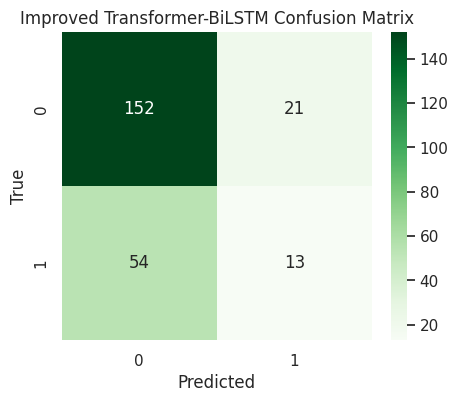

In [107]:
trans_lstm_v2.eval()

all_probs = []
all_true = []

with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb

        logits = trans_lstm_v2(xb)
        probs = torch.sigmoid(logits).squeeze().numpy()

        all_probs.extend(probs)
        all_true.extend(yb.numpy())

all_probs = np.array(all_probs)
all_true = np.array(all_true)

best_thr = 0.5
best_f1 = 0

for thr in np.arange(0.25, 0.76, 0.01):
    preds = (all_probs >= thr).astype(int)
    report = classification_report(all_true, preds, output_dict=True, zero_division=0)
    f1_class1 = report["1.0"]["f1-score"]

    if f1_class1 > best_f1:
        best_f1 = f1_class1
        best_thr = thr

print("Best threshold:", best_thr)
print("Best class 1 F1:", best_f1)

final_preds = (all_probs >= best_thr).astype(int)

print("Accuracy:", accuracy_score(all_true, final_preds))
print(classification_report(all_true, final_preds, zero_division=0))

cm = confusion_matrix(all_true, final_preds)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens")
plt.title("Improved Transformer-BiLSTM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

In [118]:
X_explain = X_test[:128]
y_explain = y_test[:128]

trans_lstm_v2.eval()

ImprovedDualAttentionBiLSTMTransformer(
  (temporal_cnn): Sequential(
    (0): Conv1d(32, 96, kernel_size=(15,), stride=(1,), padding=(7,))
    (1): BatchNorm1d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): GELU(approximate='none')
    (3): MaxPool1d(kernel_size=4, stride=4, padding=0, dilation=1, ceil_mode=False)
    (4): Conv1d(96, 96, kernel_size=(9,), stride=(1,), padding=(4,))
    (5): BatchNorm1d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): GELU(approximate='none')
    (7): MaxPool1d(kernel_size=4, stride=4, padding=0, dilation=1, ceil_mode=False)
  )
  (bilstm): LSTM(96, 64, batch_first=True, bidirectional=True)
  (lstm_proj): Linear(in_features=128, out_features=96, bias=True)
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0): TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=96, out_features=96, bias=True)
     

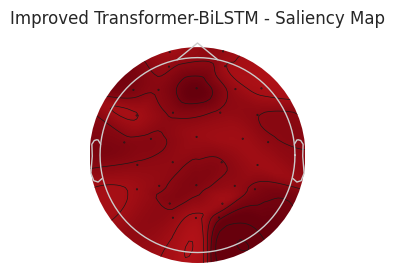

In [121]:
X_grad = X_explain.clone().detach().requires_grad_(True)

logits = trans_lstm_v2(X_grad)
loss = nn.BCEWithLogitsLoss()(logits.squeeze(), y_explain)

trans_lstm_v2.zero_grad()
loss.backward()

saliency = X_grad.grad.abs().mean(dim=(0, 2)).detach().numpy()

plot_topomap(
    saliency,
    "Improved Transformer-BiLSTM - Saliency Map"
)

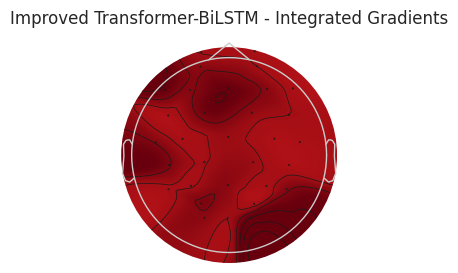

In [123]:
steps = 20
baseline = torch.zeros_like(X_explain)
ig_total = torch.zeros_like(X_explain)

for alpha in torch.linspace(0, 1, steps):
    x_step = baseline + alpha * (X_explain - baseline)
    x_step = x_step.clone().detach().requires_grad_(True)

    logits = trans_lstm_v2(x_step)
    loss = nn.BCEWithLogitsLoss()(logits.squeeze(), y_explain)

    grads = torch.autograd.grad(loss, x_step)[0]
    ig_total += grads

ig = (X_explain - baseline) * ig_total / steps
ig_importance = ig.abs().mean(dim=(0, 2)).detach().numpy()

plot_topomap(
    ig_importance,
    "Improved Transformer-BiLSTM - Integrated Gradients"
)

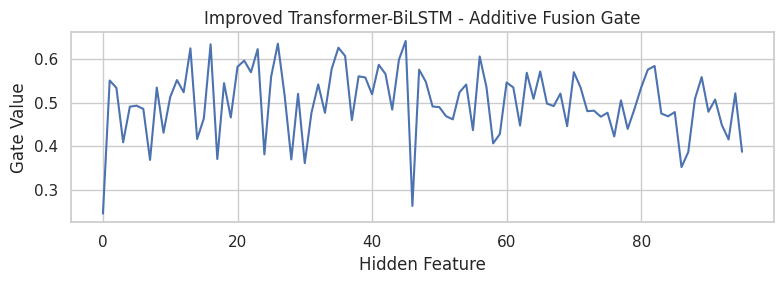

In [124]:
gate_mean = gate.mean(dim=0).detach().cpu().numpy()

plt.figure(figsize=(8, 3))
plt.plot(gate_mean)
plt.title("Improved Transformer-BiLSTM - Additive Fusion Gate")
plt.xlabel("Hidden Feature")
plt.ylabel("Gate Value")
plt.grid(True)
plt.tight_layout()
plt.show()

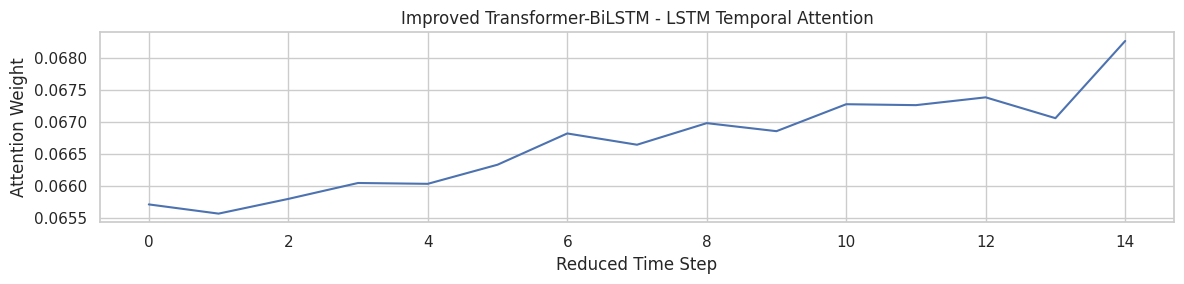

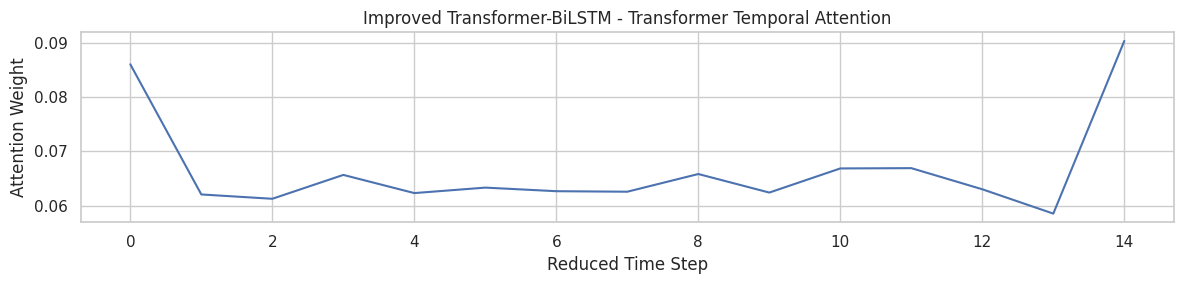

In [126]:
X_explain = X_test[:128]

trans_lstm_v2.eval()

with torch.no_grad():
    logits, lstm_att, trans_att, gate = trans_lstm_v2(
        X_explain,
        return_attention=True
    )

# LSTM attention
mean_lstm_att = lstm_att.mean(dim=0).detach().numpy()

plt.figure(figsize=(12, 3))
plt.plot(mean_lstm_att)
plt.title("Improved Transformer-BiLSTM - LSTM Temporal Attention")
plt.xlabel("Reduced Time Step")
plt.ylabel("Attention Weight")
plt.grid(True)
plt.tight_layout()
plt.show()

# Transformer attention
mean_trans_att = trans_att.mean(dim=0).detach().numpy()

plt.figure(figsize=(12, 3))
plt.plot(mean_trans_att)
plt.title("Improved Transformer-BiLSTM - Transformer Temporal Attention")
plt.xlabel("Reduced Time Step")
plt.ylabel("Attention Weight")
plt.grid(True)
plt.tight_layout()
plt.show()

final comparison 

In [128]:
import pandas as pd 

scores = {
    "BrainCompetition": brain_acc,
    "AlexNet + PCA + SVM": alex_svm_acc,
    "Transformer-BiLSTM-Attention": trans_lstm_acc,
    "Transformer-BiLSTM-Attention_optimized":trans_lstm_v2_acc
}

scores_df = pd.DataFrame({
    "Model": list(scores.keys()),
    "Accuracy": list(scores.values())
})

scores_df = scores_df.sort_values("Accuracy", ascending=False)
scores_df

,Model,Accuracy
0,BrainCompetition,0.720833
3,Transformer-BiLSTM-Attention_optimized,0.720052
2,Transformer-BiLSTM-Attention,0.695312
1,AlexNet + PCA + SVM,0.670833


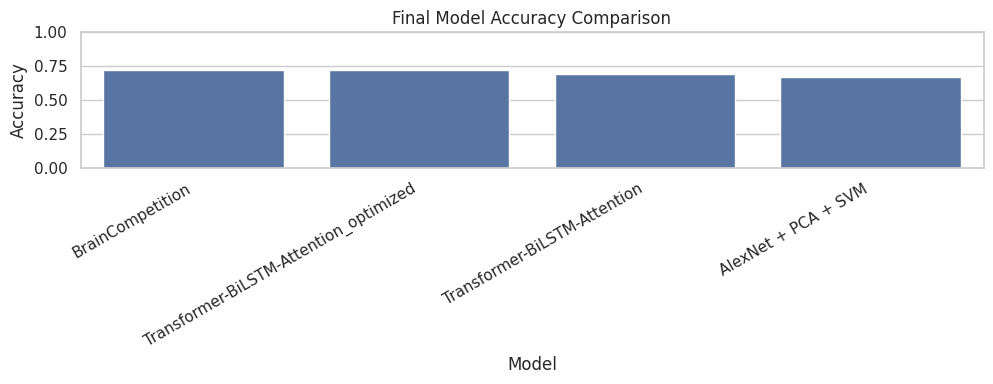

In [129]:
plt.figure(figsize=(10, 4))
sns.barplot(data=scores_df, x="Model", y="Accuracy")
plt.xticks(rotation=30, ha="right")
plt.title("Final Model Accuracy Comparison")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()